In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from shapely import wkt
import geopandas as gpd
import numpy as np
import re

In [17]:
ev_data = pd.read_csv('Electric_Vehicle_Population_Data.csv')

ev_data.head(10)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JTMAB3FV3P,Kitsap,Seabeck,WA,98380.0,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,35.0,240684006,POINT (-122.8728334 47.5798304),PUGET SOUND ENERGY INC,5.303509e+10
1,1N4AZ1CP6J,Kitsap,Bremerton,WA,98312.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,0.0,35.0,474183811,POINT (-122.6961203 47.5759584),PUGET SOUND ENERGY INC,5.303508e+10
2,5YJ3E1EA4L,King,Seattle,WA,98101.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,0.0,43.0,113120017,POINT (-122.3340795 47.6099315),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,1N4AZ0CP8E,King,Seattle,WA,98125.0,2014,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,46.0,108188713,POINT (-122.304356 47.715668),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
4,1G1FX6S00H,Thurston,Yelm,WA,98597.0,2017,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238.0,0.0,20.0,176448940,POINT (-122.5715761 46.9095798),PUGET SOUND ENERGY INC,5.306701e+10
5,5YJYGDEE5L,Snohomish,Lynnwood,WA,98036.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,21.0,124511187,POINT (-122.287143 47.812199),PUGET SOUND ENERGY INC,5.306105e+10
6,KM8S6DA23N,Kitsap,Poulsbo,WA,98370.0,2022,HYUNDAI,SANTA FE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,31.0,0.0,23.0,212217764,POINT (-122.6368884 47.7469547),PUGET SOUND ENERGY INC,5.303509e+10
7,7FCTGAAA1P,Snohomish,Arlington,WA,98223.0,2023,RIVIAN,R1T,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,39.0,252414039,POINT (-122.11597 48.194109),PUGET SOUND ENERGY INC,5.306105e+10
8,5YJYGDEE9L,King,Kent,WA,98031.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,47.0,112668510,POINT (-122.201564 47.402358),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
9,1N4AZ0CP2F,King,Kirkland,WA,98034.0,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,45.0,109765204,POINT (-122.2026532 47.7210518),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10


In [18]:
# data cleaning , missing values and handling values and standarization part 
ev_data.info()

## Looking for duplicate values

# Find duplicate rows
duplicates = ev_data[ev_data.duplicated()]

# Display duplicates
print(duplicates)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205439 entries, 0 to 205438
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         205439 non-null  object 
 1   County                                             205436 non-null  object 
 2   City                                               205436 non-null  object 
 3   State                                              205439 non-null  object 
 4   Postal Code                                        205436 non-null  float64
 5   Model Year                                         205439 non-null  int64  
 6   Make                                               205439 non-null  object 
 7   Model                                              205438 non-null  object 
 8   Electric Vehicle Type                              205439 non-null  object

In [19]:
print("\nMissing Values Summary:")
print(ev_data.isnull().sum())


Missing Values Summary:
VIN (1-10)                                             0
County                                                 3
City                                                   3
State                                                  0
Postal Code                                            3
Model Year                                             0
Make                                                   0
Model                                                  1
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         8
Base MSRP                                              8
Legislative District                                 442
DOL Vehicle ID                                         0
Vehicle Location                                       8
Electric Utility                                       3
2020 Census Tract                                      3
dtype:

In [20]:
# Step 2: Data Cleaning and Standardization
# Drop rows where Electric Range or MSRP is null as they are crucial for analysis
data = ev_data.dropna(subset=['Electric Range', 'Base MSRP'])

print("\nMissing Values Summary:")
print(data.isnull().sum())


Missing Values Summary:
VIN (1-10)                                             0
County                                                 3
City                                                   3
State                                                  0
Postal Code                                            3
Model Year                                             0
Make                                                   0
Model                                                  1
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 442
DOL Vehicle ID                                         0
Vehicle Location                                       8
Electric Utility                                       3
2020 Census Tract                                      3
dtype:

In [21]:

def extract_coordinates(point_str):
    """
    Extract coordinates from a string in format 'POINT (-122.8728334 47.5798304)'
    Returns tuple of (longitude, latitude)
    """
    # Extract numbers using regex
    matches = re.findall(r'-?\d+\.\d+', str(point_str))
    if len(matches) == 2:
        return float(matches[0]), float(matches[1])
    return None, None

def process_vehicle_locations(data):
    """
    Process the vehicle location data and extract coordinates
    """
    # Ensure we're working with strings and handle nulls
    data = data.copy()
    data = data[data['Vehicle Location'].notna()]
    
    # Extract coordinates
    coordinates = data['Vehicle Location'].apply(extract_coordinates)
    
    # Split into latitude and longitude columns
    data['Longitude'], data['Latitude'] = zip(*coordinates)
    
    # Remove rows where coordinate extraction failed
    data = data[data['Latitude'].notna() & data['Longitude'].notna()]
    
    return data

# Process the data
processed_data = process_vehicle_locations(data)

# Verify results
print("\nSample of extracted coordinates:")
print(processed_data[['Vehicle Location', 'Latitude', 'Longitude']].head())

# Basic statistics
print("\nCoordinate Statistics:")
print("\nLatitude Statistics:")
print(processed_data['Latitude'].describe())
print("\nLongitude Statistics:")
print(processed_data['Longitude'].describe())

# Verify coordinate ranges for Washington State
print("\nCoordinate Range Verification:")
print(f"Latitude Range: {processed_data['Latitude'].min():.4f} to {processed_data['Latitude'].max():.4f}")
print(f"Longitude Range: {processed_data['Longitude'].min():.4f} to {processed_data['Longitude'].max():.4f}")

# Save the cleaned data
processed_data.to_csv('Electric_Vehicle_Population_Cleaned_Data.csv', index=False)
print("\nCleaned data saved to 'Electric_Vehicle_Population_Cleaned_Data.csv'")



Sample of extracted coordinates:
                  Vehicle Location   Latitude   Longitude
0  POINT (-122.8728334 47.5798304)  47.579830 -122.872833
1  POINT (-122.6961203 47.5759584)  47.575958 -122.696120
2  POINT (-122.3340795 47.6099315)  47.609932 -122.334080
3    POINT (-122.304356 47.715668)  47.715668 -122.304356
4  POINT (-122.5715761 46.9095798)  46.909580 -122.571576

Coordinate Statistics:

Latitude Statistics:
count    205423.000000
mean         47.437761
std           0.814457
min          20.735185
25%          47.358111
50%          47.610347
75%          47.721052
max          61.318822
Name: Latitude, dtype: float64

Longitude Statistics:
count    205423.000000
mean       -122.021742
std           1.796924
min        -159.712613
25%        -122.395519
50%        -122.275332
75%        -122.136803
max         -70.743216
Name: Longitude, dtype: float64

Coordinate Range Verification:
Latitude Range: 20.7352 to 61.3188
Longitude Range: -159.7126 to -70.7432

Cleaned dat

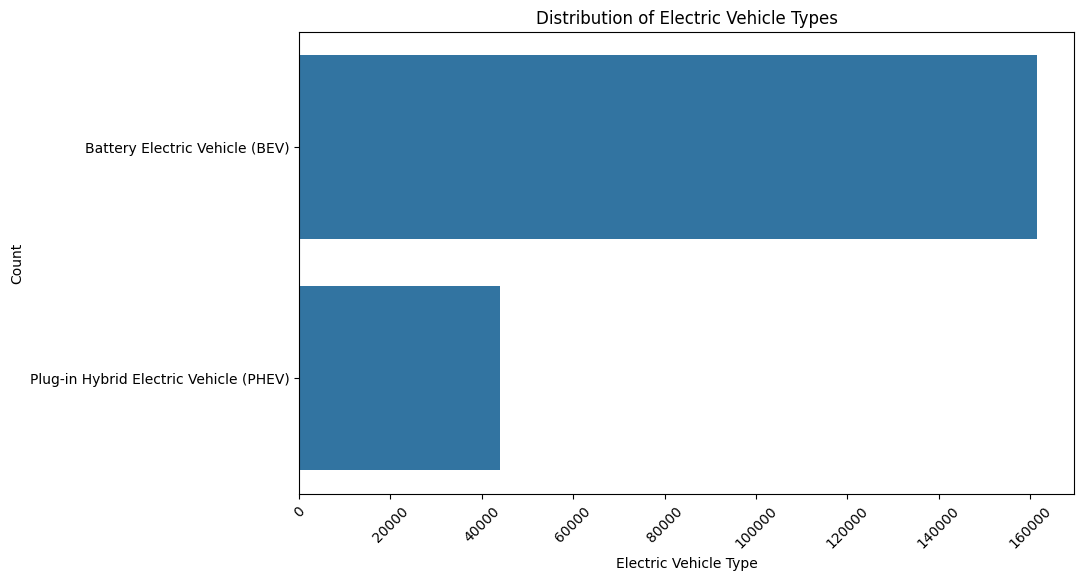

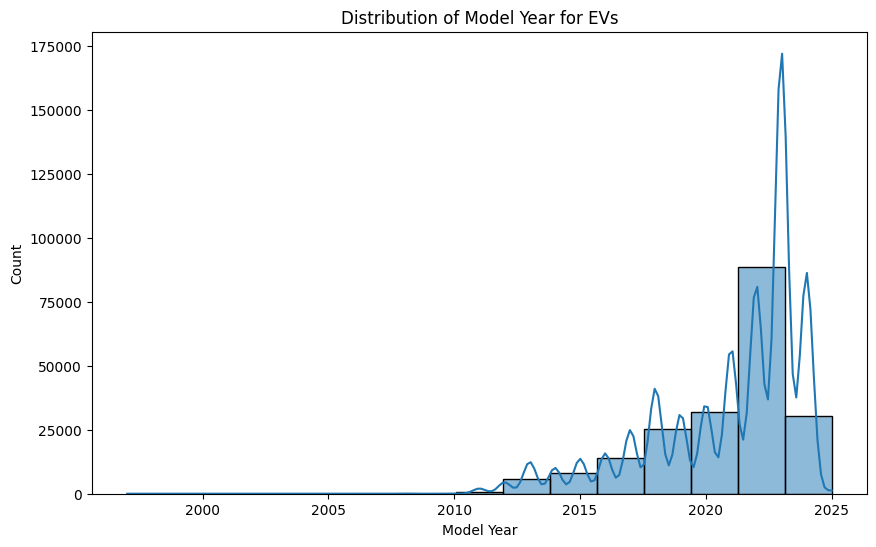

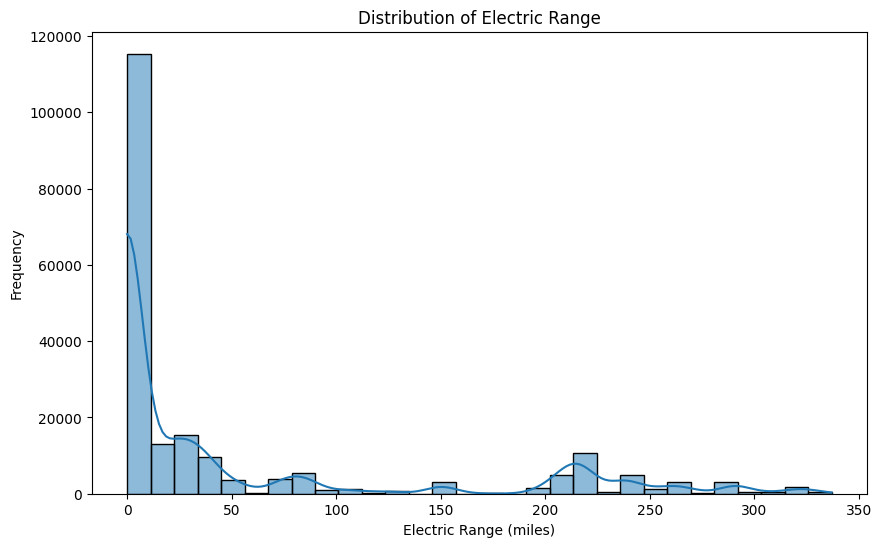

In [22]:
# Step 3: Univariate Analysis - Basic plots for distributions

# Distribution of EV Types
plt.figure(figsize=(10, 6))
sns.countplot(ev_data['Electric Vehicle Type'], order=ev_data['Electric Vehicle Type'].value_counts().index)
plt.title('Distribution of Electric Vehicle Types')
plt.xlabel('Electric Vehicle Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Model Year Distribution
plt.figure(figsize=(10, 6))
sns.histplot(ev_data['Model Year'], bins=15, kde=True)
plt.title('Distribution of Model Year for EVs')
plt.xlabel('Model Year')
plt.ylabel('Count')
plt.show()

# Distribution of Electric Range
plt.figure(figsize=(10, 6))
sns.histplot(ev_data['Electric Range'], bins=30, kde=True)
plt.title('Distribution of Electric Range')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Frequency')
plt.show()


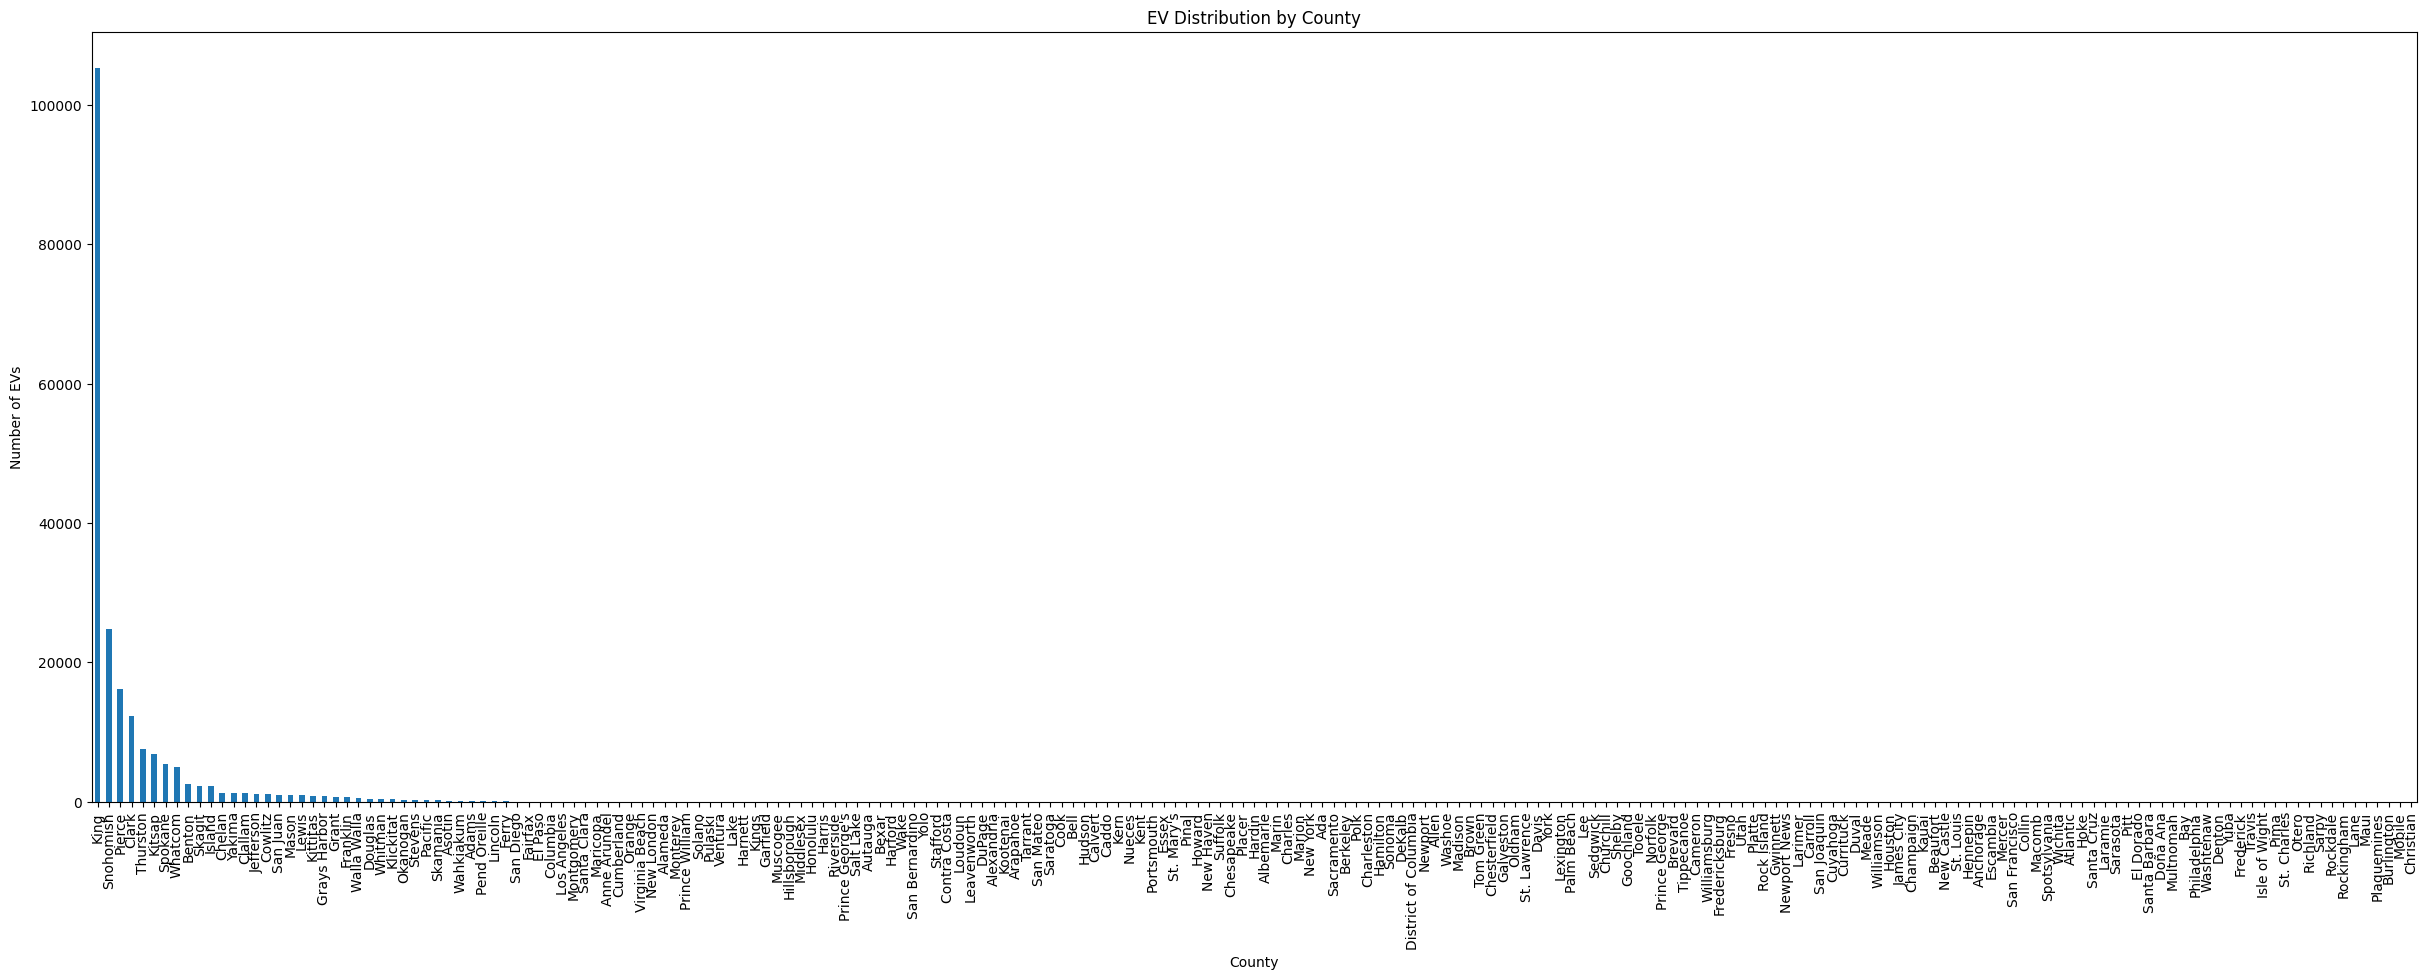

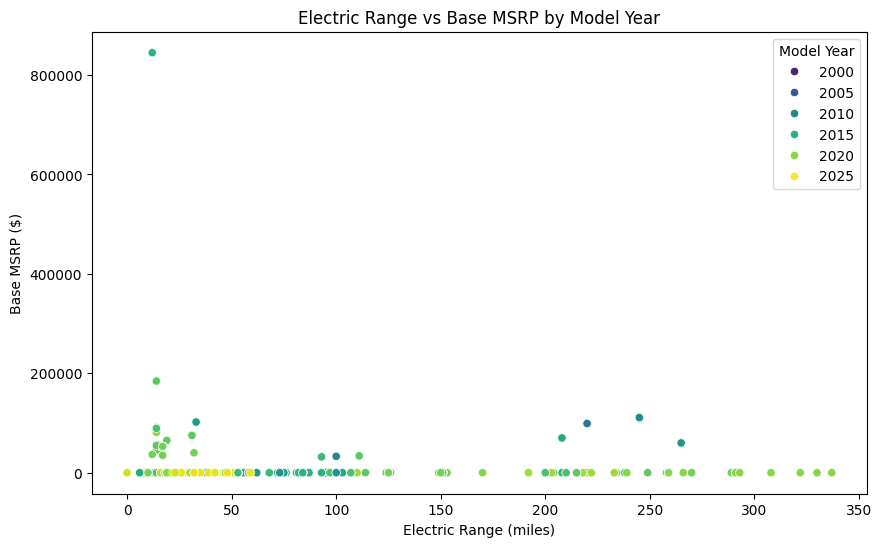

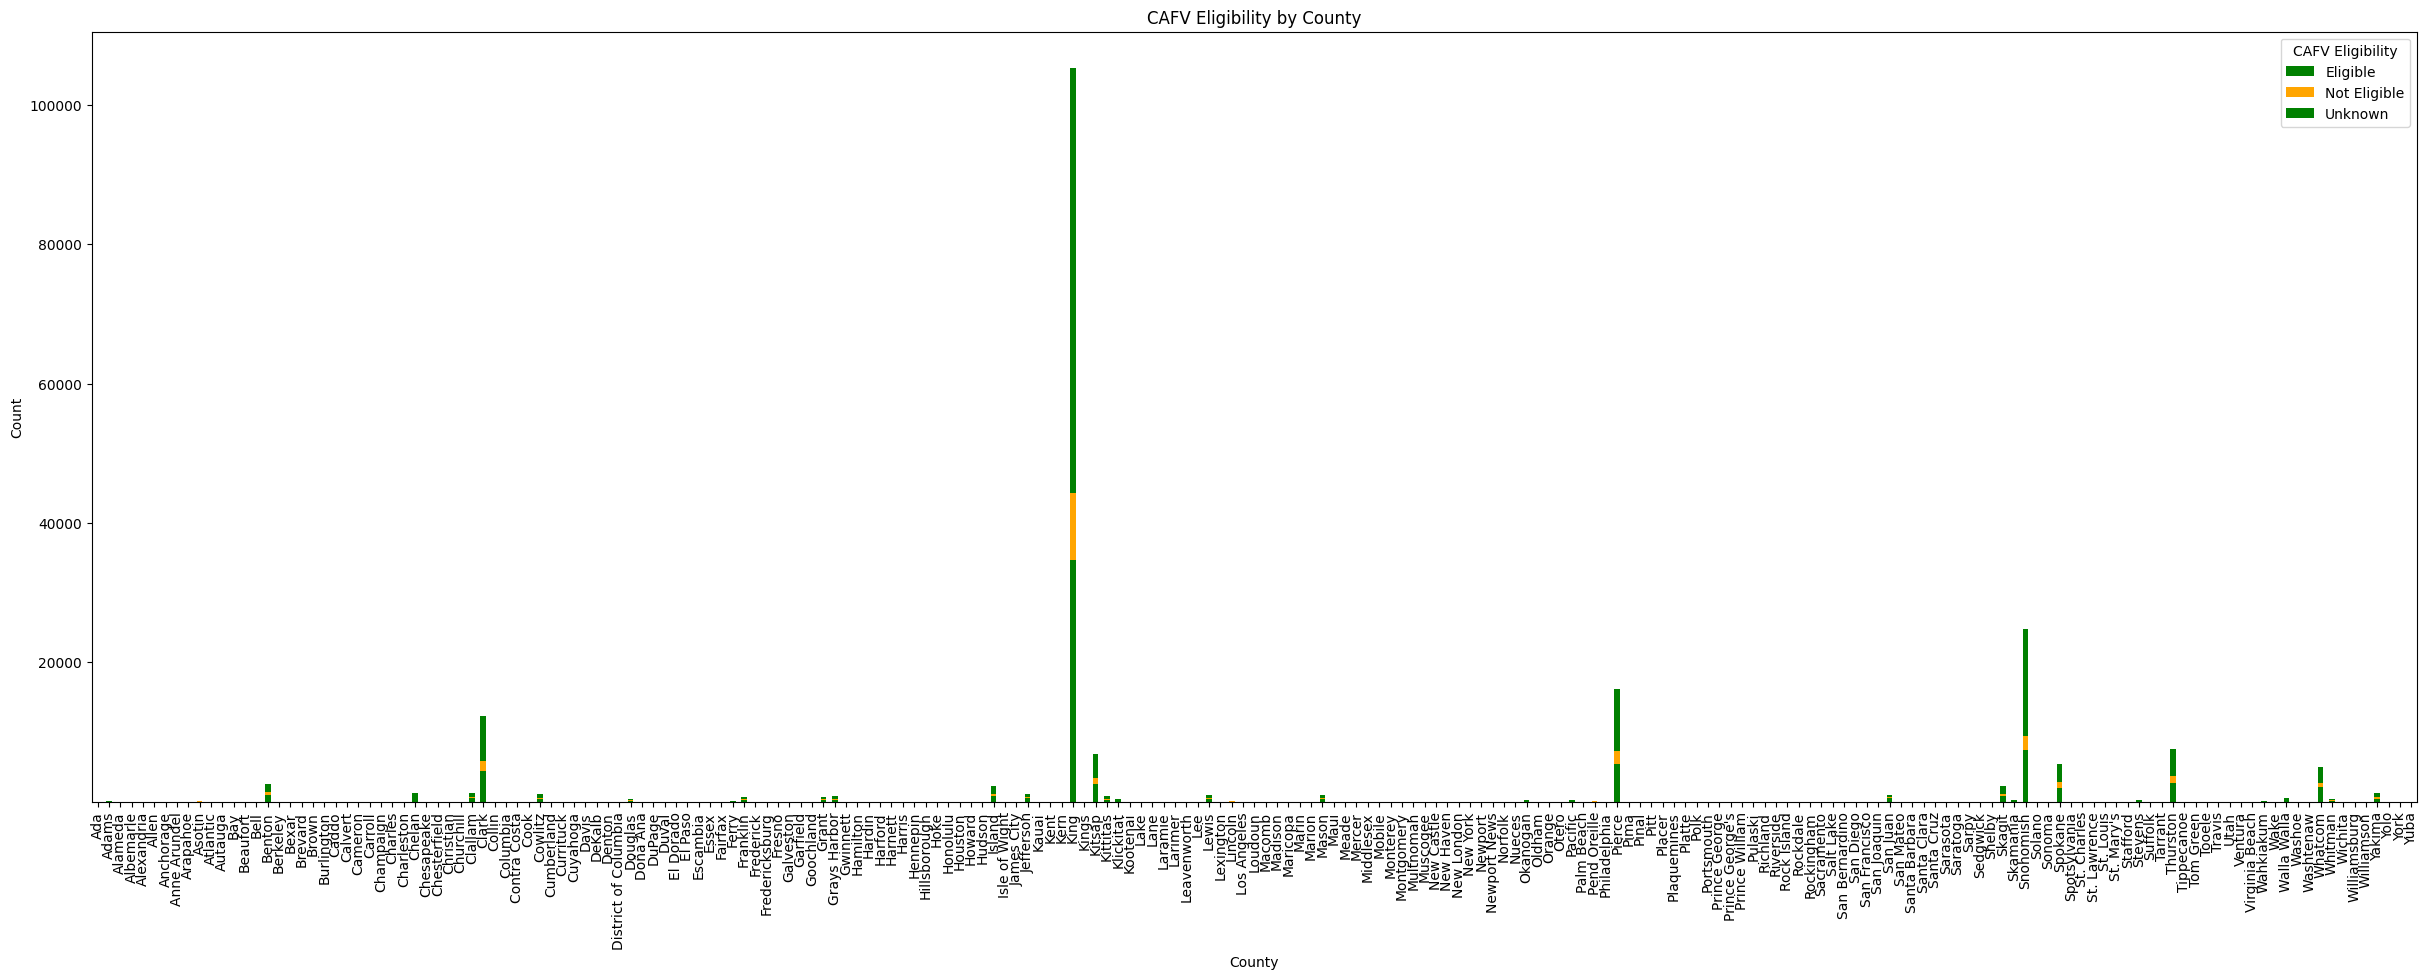

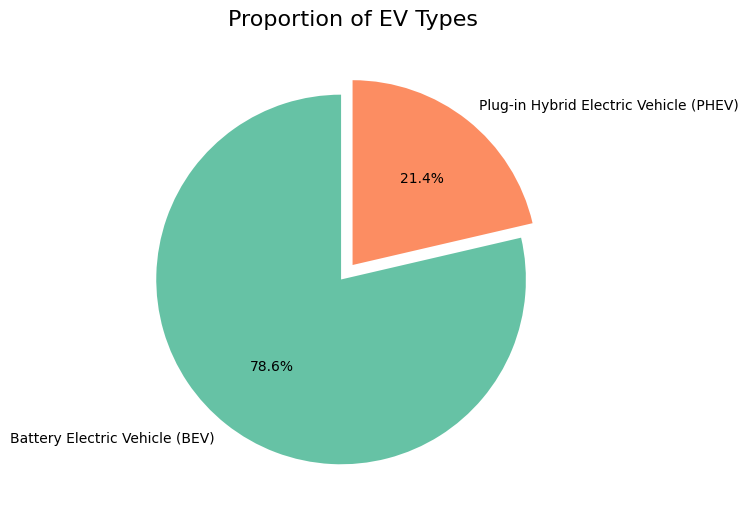

In [28]:
# Step 4: Bivariate and Multivariate Analysis

# Geographic Analysis - Number of EVs by County
county_counts = ev_data['County'].value_counts()
plt.figure(figsize=(30, 10))
county_counts.plot(kind='bar')
plt.title('EV Distribution by County')
plt.xlabel('County')
plt.ylabel('Number of EVs')
plt.xticks(rotation=90)
plt.show()

# we should check for the country names is uniques , only take those country which is impacting thenumber of ev 
# and sort those which has less amount of electric cars , find why they don't have that much electric cars.

#----------------------------------------------------------------------------------------

# Correlation Analysis - Electric Range vs MSRP and Model Year
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Electric Range', y='Base MSRP', hue='Model Year', data=ev_data, palette='viridis')
plt.title('Electric Range vs Base MSRP by Model Year')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Base MSRP ($)')
plt.legend(title='Model Year')
plt.show()

# CAFV Eligibility by County
cafv_counts = ev_data.groupby('County')['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts().unstack().fillna(0)
cafv_counts.plot(kind='bar', stacked=True, figsize=(30, 10), color=['green', 'orange'])
plt.title('CAFV Eligibility by County')
plt.xlabel('County')
plt.ylabel('Count')
plt.legend(title='CAFV Eligibility')
plt.xticks(rotation=90)
plt.show()

# Chart 2: Proportion of EV Types Across All Counties

# Count of EV Types across all counties
ev_type_total = ev_data['Electric Vehicle Type'].value_counts(normalize=True) * 100

# Plot EV Type proportions
plt.figure(figsize=(8, 6))
ev_type_total.plot(kind='pie', autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], explode=(0.1, 0), startangle=90)
plt.title('Proportion of EV Types', fontsize=16)
plt.ylabel('')  # Remove y-axis label
plt.show()

# Key Takeaways:

# Chart 1: Highlights geographical distribution of EV types, showing counties with a higher preference for BEVs (e.g., Tesla) versus PHEVs.
# Chart 2: Summarizes the overall proportion of EV types, which could be helpful in determining national-level adoption trends.

C:\Users\sakib\AppData\Local\Temp\ipykernel_2168\436278811.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=ev_data, x='Incentive Category', y='Electric Range', ci=None)


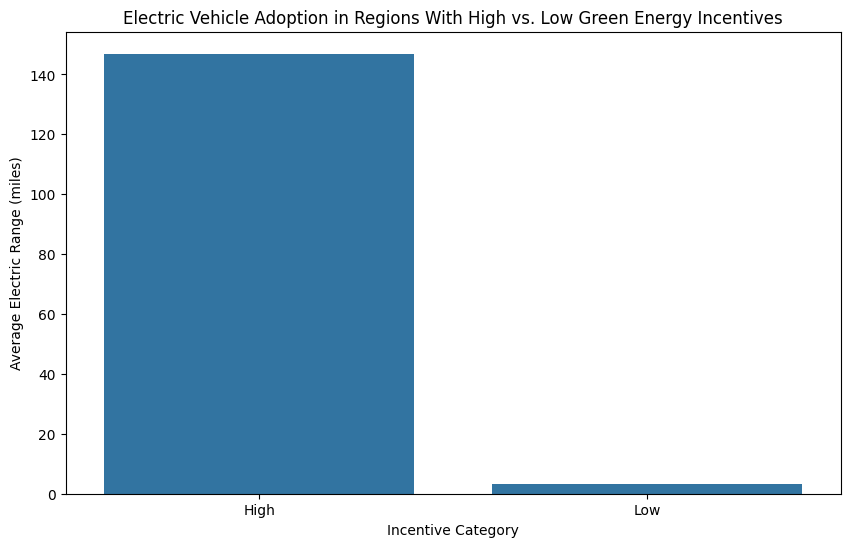

In [24]:
# Chart 2: Adoption of Electric Vehicles in High vs. Low Incentive Regions
# We'll split based on CAFV Eligibility being True (High Incentive) vs False (Low Incentive)

ev_data['Incentive Category'] = ev_data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].apply(
    lambda x: 'High' if x == 'Clean Alternative Fuel Vehicle Eligible' else 'Low')

# Now, create a bar chart to compare Electric Range or Base MSRP in High vs Low incentive regions
plt.figure(figsize=(10, 6))
sns.barplot(data=ev_data, x='Incentive Category', y='Electric Range', ci=None)
plt.title('Electric Vehicle Adoption in Regions With High vs. Low Green Energy Incentives')
plt.xlabel('Incentive Category')
plt.ylabel('Average Electric Range (miles)')
plt.show()

<Figure size 1400x800 with 0 Axes>

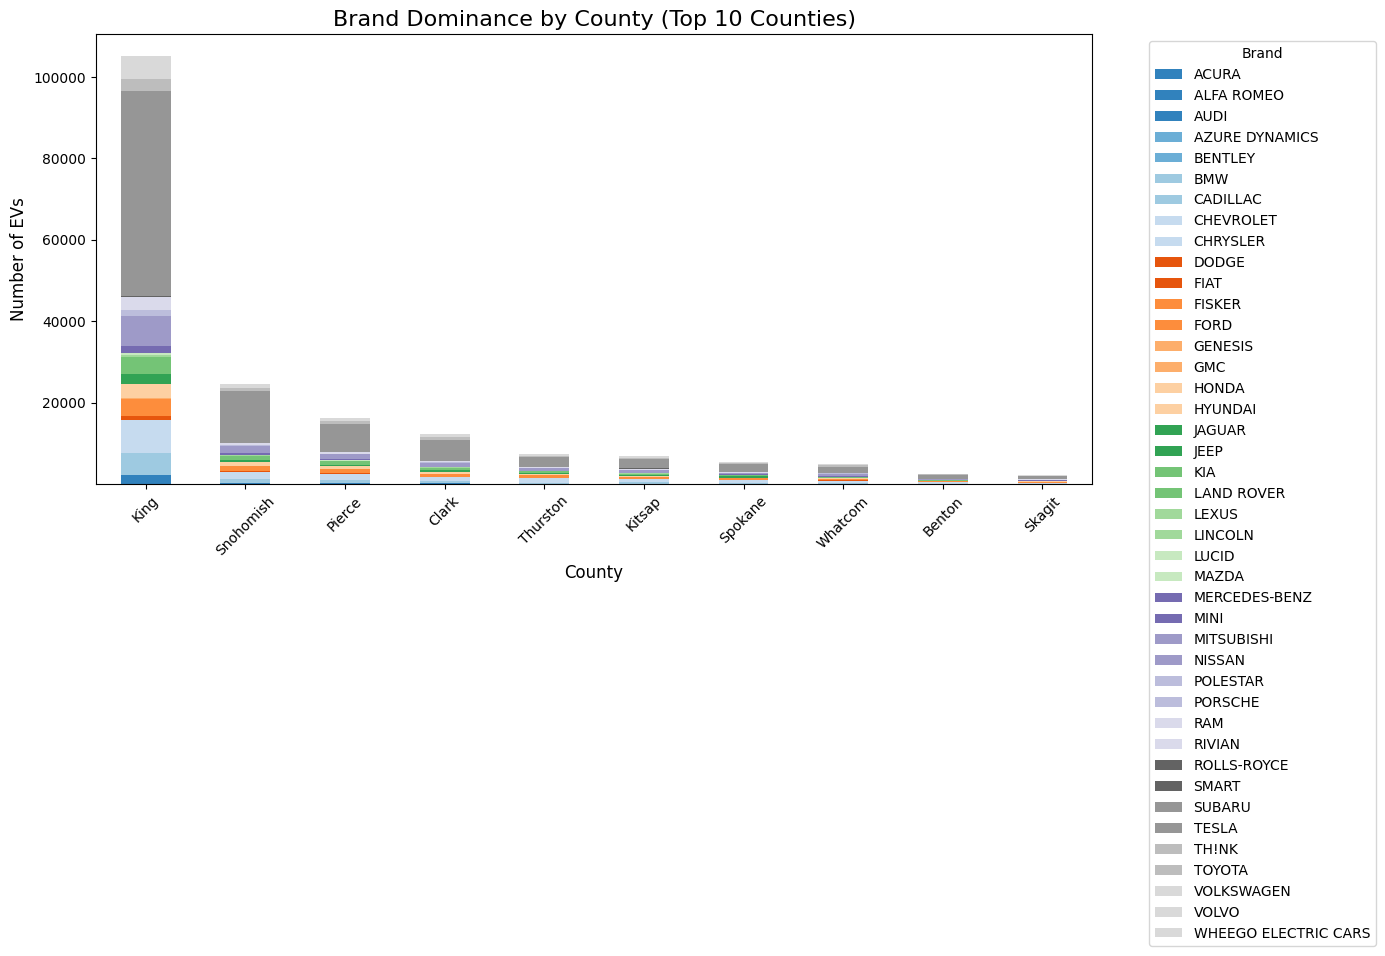

C:\Users\sakib\AppData\Local\Temp\ipykernel_2168\1478168517.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_total.values, y=brand_total.index, palette='viridis')


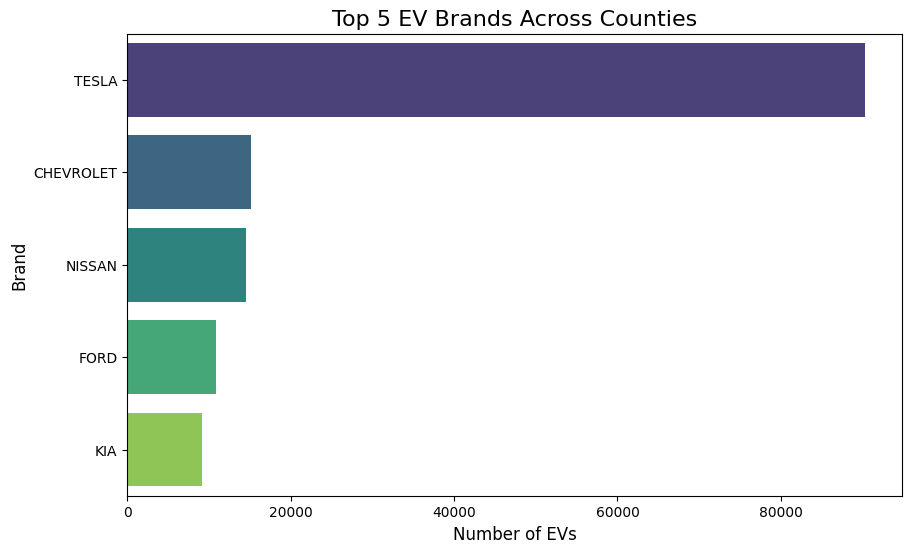

In [25]:
#------------------------------------------------------------------------
#1. Brand Dominance
#Chart 1: EV Brand Distribution by County (Top 10 Counties)


# Group data by County and Make (Brand)
brand_county = ev_data.groupby(['County', 'Make']).size().unstack(fill_value=0)

# Plot the top brands for each county as a stacked bar chart
plt.figure(figsize=(14, 8))
top_counties = brand_county.loc[brand_county.sum(axis=1).nlargest(10).index]
top_counties.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20c')

plt.title('Brand Dominance by County (Top 10 Counties)', fontsize=16)
plt.xlabel('County', fontsize=12)
plt.ylabel('Number of EVs', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#Chart 2: Top 5 Brands Across All Counties

# Count of EVs by Make (Top 5 brands)
brand_total = ev_data['Make'].value_counts().nlargest(5)

# Plot the top brands
plt.figure(figsize=(10, 6))
sns.barplot(x=brand_total.values, y=brand_total.index, palette='viridis')
plt.title('Top 5 EV Brands Across Counties', fontsize=16)
plt.xlabel('Number of EVs', fontsize=12)
plt.ylabel('Brand', fontsize=12)
plt.show()



#Key Takeaways:

#Chart 1: Reveals which brands dominate in specific counties, highlighting regional preferences. For example, Tesla might dominate in urban counties, while Nissan could be popular in suburban/rural areas.
#Chart 2: Shows the overall brand dominance across the dataset, emphasizing the popularity of specific brands (e.g., Tesla).

C:\Users\sakib\AppData\Local\Temp\ipykernel_2168\3903914139.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cafv_distribution.values, y=cafv_distribution.index, palette='coolwarm')


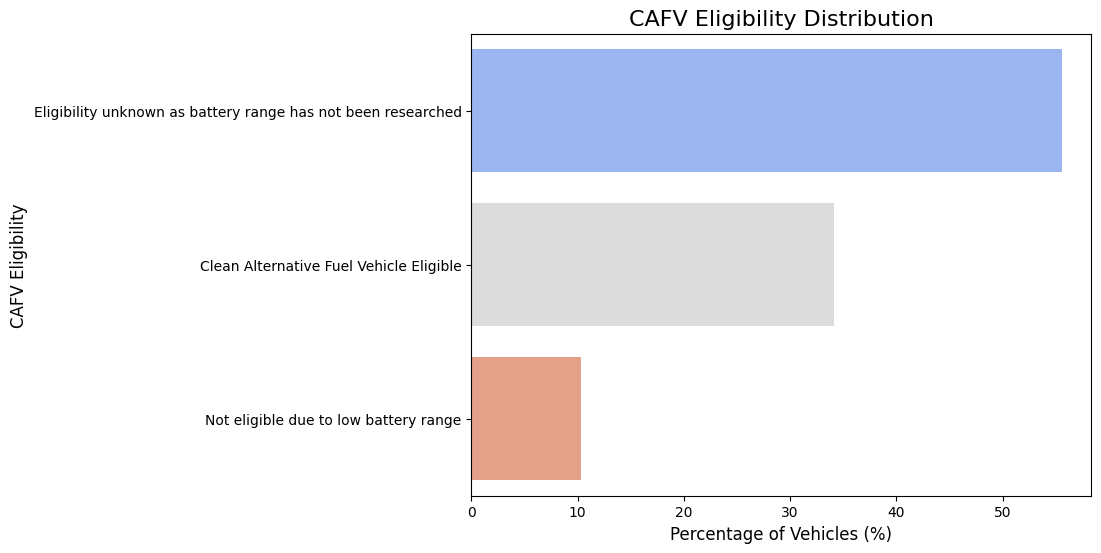

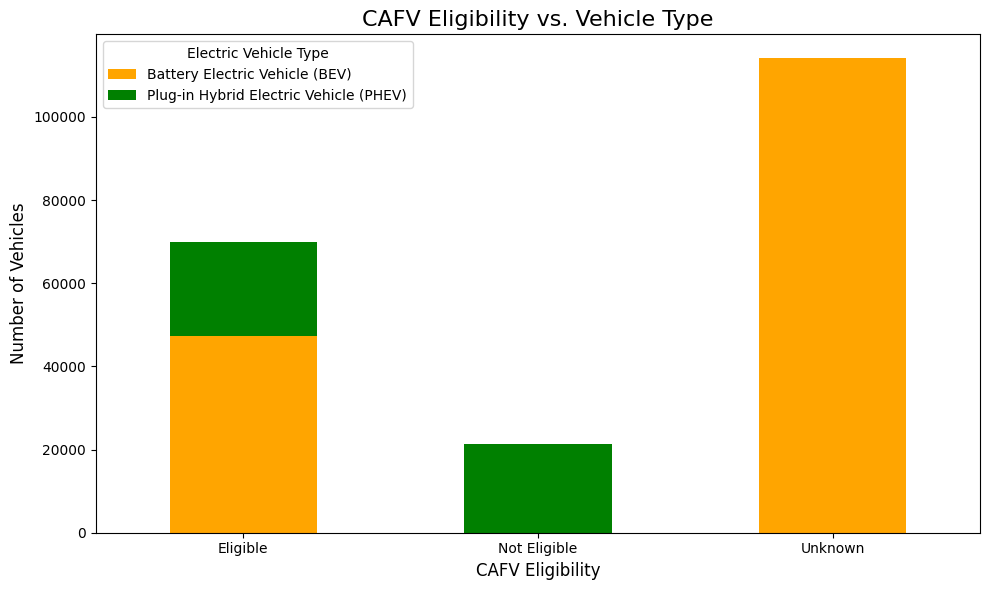

In [26]:
#1. CAFV Eligibility Distribution (Bar Chart)
#This chart shows the proportion of registered EVs that are eligible for CAFV incentives.


# Distribution of CAFV Eligibility
cafv_distribution = ev_data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts(normalize=True) * 100

# Plot the CAFV Eligibility distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=cafv_distribution.values, y=cafv_distribution.index, palette='coolwarm')
plt.title('CAFV Eligibility Distribution', fontsize=16)
plt.xlabel('Percentage of Vehicles (%)', fontsize=12)
plt.ylabel('CAFV Eligibility', fontsize=12)
plt.show()


# Key Takeaway:

# The chart highlights the proportion of EVs eligible for CAFV incentives, indicating how widespread the program's impact is. A higher proportion of eligible vehicles suggests strong alignment between the program and consumer behavior.

#2. Vehicle Type vs. CAFV Eligibility (Stacked Bar Chart)
# This chart compares BEVs and PHEVs based on their CAFV eligibility.



# Clean the CAFV_Eligibility values
ev_data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] = ev_data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].replace(
    {'Clean Alternative Fuel Vehicle Eligible': 'Eligible',
     'Eligibility unknown as battery range has not been researched': 'Unknown',
     'Not eligible due to low battery range': 'Not Eligible'}
)

# Group data by CAFV Eligibility and Electric Vehicle Type
vehicle_cafv = ev_data.groupby(['Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Vehicle Type']).size().unstack(fill_value=0)

# Plot the relationship as a stacked bar chart
vehicle_cafv.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#FFA500', '#008000', '#FF0000'])
plt.title('CAFV Eligibility vs. Vehicle Type', fontsize=16)
plt.xlabel('CAFV Eligibility', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.legend(title='Electric Vehicle Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Key Takeaway:

# This chart reveals that BEVs constitute a larger proportion of CAFV-eligible vehicles compared to PHEVs. It suggests that CAFV incentives might be more effective for fully electric vehicles, aligning with their environmental benefits.


# Insights from the Charts

# CAFV Eligibility Distribution:

# The majority of vehicles being CAFV-eligible underscores the effectiveness of the program.
# A deeper look at non-eligible vehicles could identify opportunities for policy improvements.

# BEVs are more likely to be CAFV-eligible, indicating the program’s preference for fully electric vehicles.
# This could influence stakeholders to focus on BEVs for higher impact.

# Geographic Distribution:

# Identifies regions with lower CAFV-eligible vehicle density.
# Enables targeted interventions to improve green energy adoption.

# Unknown' is the predominant eligibility type for most vehicles, with Battery Electric Vehicles (BEV) leading in manufacturing.

In [27]:
vehicle_cafv_by_county = ev_data.groupby('County')['CAFV Eligible'].sum().reset_index()
print(vehicle_cafv_by_county.sort_values(by='CAFV Eligible', ascending=False).head(10))  # Check top counties


KeyError: 'Column not found: CAFV Eligible'

Clean Alternative Fuel Vehicle (CAFV) Eligibility
Unknown         114172
Eligible         70008
Not Eligible     21251
Name: count, dtype: int64


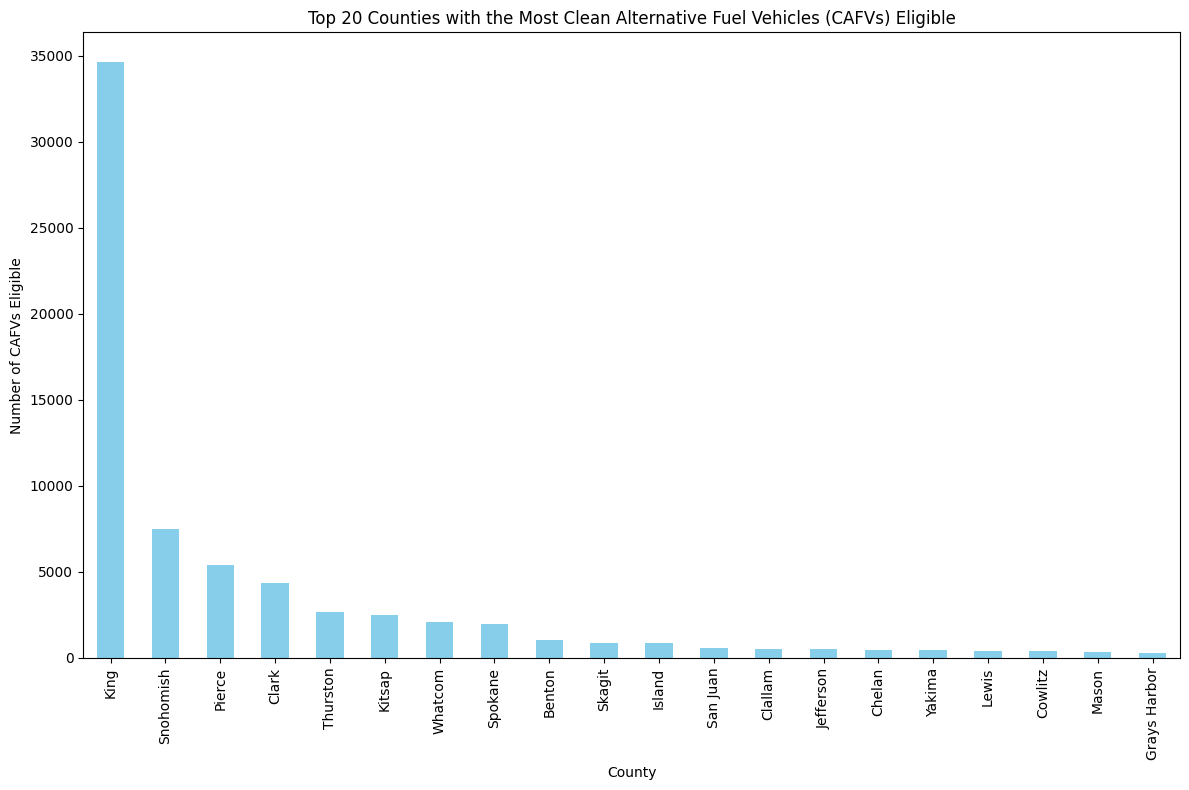

In [ ]:
# Ensure the 'Clean Alternative Fuel Vehicle (CAFV) Eligibility' column is properly cleaned
ev_data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] = ev_data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].replace(
    {'Clean Alternative Fuel Vehicle Eligible': 'Eligible',
     'Eligibility unknown as battery range has not been researched': 'Unknown',
     'Not eligible due to low battery range': 'Not Eligible'}
)

# Check if the cleaning was successful
print(ev_data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts())

# Filter the data to include only those vehicles that are eligible
eligible_ev_data = ev_data[ev_data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Eligible']

# Check if there is any data for eligible vehicles
if eligible_ev_data.empty:
    print("No data for 'Eligible' Clean Alternative Fuel Vehicles")
else:
    # Count the number of eligible vehicles for each county
    county_counts = eligible_ev_data['County'].value_counts()

    # Get the top 20 counties with the most eligible vehicles
    top_20_counties = county_counts.head(20)

    # Plotting the bar chart for top 20 counties
    plt.figure(figsize=(12, 8))
    top_20_counties.plot(kind='bar', color='skyblue')
    plt.title('Top 20 Counties with the Most Clean Alternative Fuel Vehicles (CAFVs) Eligible')
    plt.xlabel('County')
    plt.ylabel('Number of CAFVs Eligible')
    plt.xticks(rotation=90)  # Rotate the x-axis labels to fit them better
    plt.tight_layout()  # Adjust layout to avoid clipping
    plt.show()


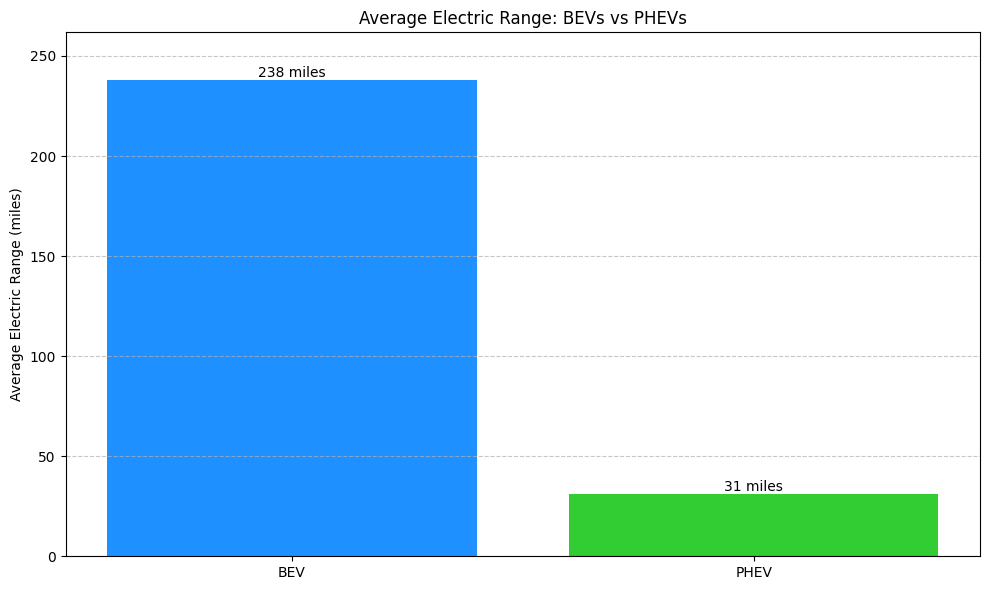

In [ ]:
# Data
vehicle_types = ['BEV', 'PHEV']
avg_ranges = [238, 31]

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(vehicle_types, avg_ranges, color=['#1e90ff', '#32cd32'])

# Customize the chart
ax.set_ylabel('Average Electric Range (miles)')
ax.set_title('Average Electric Range: BEVs vs PHEVs')
ax.set_ylim(0, max(avg_ranges) * 1.1)  # Set y-axis limit with some padding

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height} miles',
            ha='center', va='bottom')

# Add a light grid for better readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Improve overall layout
plt.tight_layout()

# Show the plot
plt.show()